### DBSCAN Clustering on Energy Dataset (Optimized for Large Datasets)
# This notebook performs DBSCAN clustering using PCA reduction and memory-optimized preprocessing.
# It includes full markdown explanations, section titles, and a final conclusion.

In [72]:
import pandas as pd
import gc
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler
from rice_ml.unsupervised_learning.dbscan import (
    load_dataset,
    select_numeric,
    scale_features,
    compute_k_distance,
    run_dbscan,
    add_cluster_labels,
    plot_k_distance,
    plot_clusters,
)


In [73]:
energy_df = load_dataset(("../../../datasets/energy.csv"))
energy_df.head()


,Unnamed: 0,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,4,2001,1,AK,Total Electric Power Industry,Wind,87.0


In [74]:
# We filter the dataset to keep only numeric columns.
numeric_df = select_numeric(energy_df)
numeric_df.head()


,Unnamed: 0,YEAR,MONTH,GENERATION (Megawatthours)
0,0,2001,1,46903.0
1,1,2001,1,71085.0
2,2,2001,1,367521.0
3,3,2001,1,104549.0
4,4,2001,1,87.0


In [75]:
sampled_df = numeric_df.sample(n=50000, random_state=42)
sampled_df.head()

,Unnamed: 0,YEAR,MONTH,GENERATION (Megawatthours)
145911,61976,2007,11,7499.00
484438,23672,2021,12,0.00
6201,6201,2001,4,306704.00
220057,26073,2011,2,4250.41
383802,24126,2017,12,109212.00


In [76]:
scaled_data = scale_features(sampled_df)
scaled_data[:5]


array([[ 3.27867284, -0.75459099,  1.32729784, -0.13255459],
       [ 0.41624852,  1.51232328,  1.61680377, -0.13327771],
       [-0.88934399, -1.72612567, -0.69924368, -0.10370246],
       [ 0.59567314, -0.1069012 , -1.27825554, -0.13286785],
       [ 0.45017554,  0.86463349,  1.61680377, -0.12274647]])

In [77]:
numeric_df = None
gc.collect()

17635

In [78]:
ipca = IncrementalPCA(n_components=2, batch_size=5000)
reduced = ipca.fit_transform(scaled_data)


pca_df = pd.DataFrame(reduced, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,3.365598,0.322760
1,0.566010,1.816202
2,-0.285133,-1.383437
3,-0.277652,-0.577089
4,0.867520,1.401325


In [79]:
pca = IncrementalPCA(n_components=2) # Reduce to 2D for clustering and visualization
reduced = pca.fit_transform(scaled_data)


pca_df = pd.DataFrame(reduced, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,3.367509,-0.294949
1,0.572179,-0.887426
2,-0.290936,0.530632
3,-0.278879,0.170013
4,0.872023,-0.708161


In [80]:
scaled_data = None
gc.collect()

0

In [81]:
scaler_pca = StandardScaler()
pca_scaled = scaler_pca.fit_transform(reduced)

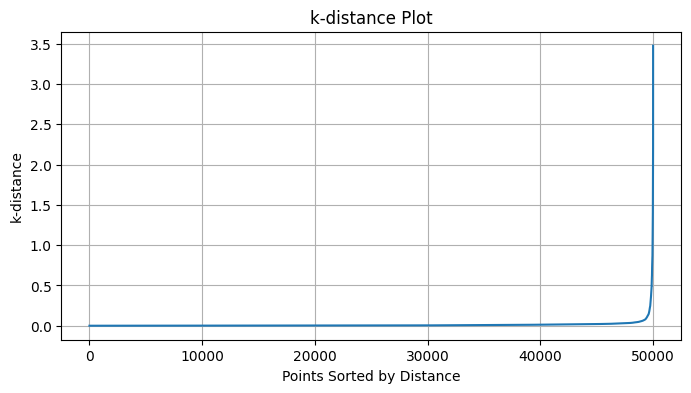

In [82]:
k_distances = compute_k_distance(pca_scaled, k=5)
plot_k_distance(k_distances)


In [83]:
# Adjust these values after inspecting the k-distance ploteps_value = 1.5
eps_value = 0.1
min_samples_value = 5


In [84]:
labels = run_dbscan(pca_scaled, eps=eps_value, min_samples=min_samples_value)
labels[:20]

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [85]:
len(set(labels))


15

In [86]:
clustered_df = add_cluster_labels(pca_df, labels)

clustered_df.head()

,PC1,PC2,cluster
0,3.367509,-0.294949,0
1,0.572179,-0.887426,1
2,-0.290936,0.530632,1
3,-0.278879,0.170013,1
4,0.872023,-0.708161,1


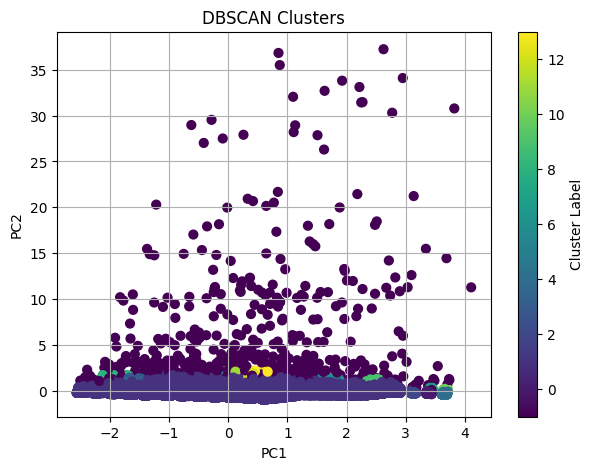

In [87]:
plot_clusters(pca_df, labels, "PC1", "PC2")

In [88]:
clustered_df["cluster"].value_counts()

cluster
 1     48904
-1       498
 2       176
 4       166
 0       156
 3        13
 8        13
 5        12
 9        12
 12       11
 6        10
 10       10
 7         7
 13        7
 11        5
Name: count, dtype: int64

In [89]:
eps_values = [0.12, 0.15, 0.18, 0.2]


In [90]:
for eps in eps_values:
    labels_test = run_dbscan(pca_scaled, eps=eps, min_samples=10)
    print(eps, len(set(labels_test)))


0.12 7
0.15 6
0.18 3
0.2 3


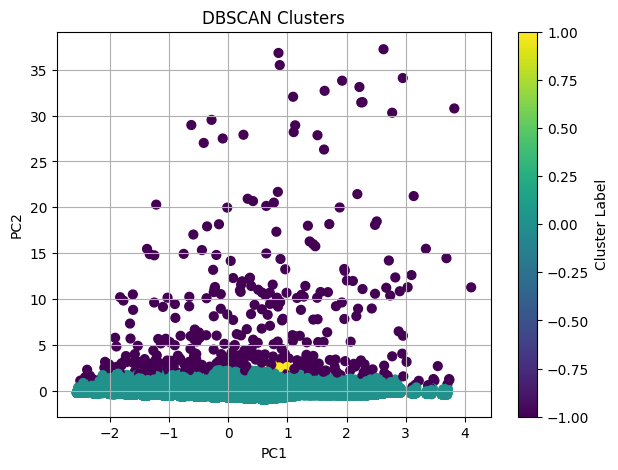

In [91]:
final_eps = 0.18
labels_final = run_dbscan(pca_scaled, eps=final_eps, min_samples=10)
plot_clusters(pca_df, labels_final, "PC1", "PC2")
